# Data Cleaning

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from utils.setting import config
config()

In [13]:
# -------------
# Stacking the data
# -------------
class DataScaler:

    def __init__(self, sub_names):
        self.time_scaler = MinMaxScaler()
        self.mark_scaler = MinMaxScaler()
        self.sub_names = sub_names

    def fit_transform(self, df_out):
        time    = self.time_scaler.fit_transform(df_out[['Time']].values.reshape(-1, 1))
        marks   = self.mark_scaler.fit_transform(
            np.log(df_out[['CI', 'Duration']].values.reshape(-1, 2))
            )
        index   = df_out['Sub Index'].values.reshape(-1, 1)
        data    = np.concatenate([time, index, marks], -1) # [ n_out, 4 ] np
        return data
    
    def inverse_time(self, time):
        '''
        Input 1d array, return 1d date array
        '''
        date = self.time_scaler.inverse_transform(time.reshape(-1, 1))
        date = pd.to_datetime(date.reshape(-1))
        return date
    
    def inverse_mark(self, mark):
        '''
        Input 2d mark, return 2d original mark 
        '''
        mark = self.mark_scaler.inverse_transform(mark)
        mark = np.exp(mark)
        return mark
    
    def inverse_space(self, index):
        '''
        Input 1d space index, return 1d substation names 
        '''
        names = self.sub_names[index.astype(int)]
        return names
    
    def transform_time(self, date):
        '''
        Input 1d array, return 1d time array
        '''
        time = self.time_scaler.transform(date.values.reshape(-1, 1)).reshape(-1)
        return time

In [14]:
df = pd.read_csv(r'data\7_1_2_cov_weather.csv', index_col=0)

cov = []
for attr in [*df.columns[2:-3]]:
    mdf = df.pivot(index="substation", columns='month', values = attr)
    cov.append(mdf.values)
cov = np.stack(cov, -1)     # [ n_sub, n_month, n_attr ] np

rows = mdf.index
cols = mdf.columns

# normalize cov matrix to avoid numerical optimization issues 
from sklearn.preprocessing import MinMaxScaler
cov = MinMaxScaler().fit_transform(cov.reshape(-1, cov.shape[2])).reshape(*cov.shape)

In [15]:
start_time  = '2014-01'
pred_time   = '2024-01' 
# end_time    = '2039-12' 
end_time    = '2040-01' 
cal_time    = '2015-01'

cov_dates   = pd.date_range(start=start_time, end=end_time, freq='MS') 

# -------------
# Init
# -------------
df_out  = pd.read_csv(r'data\8_20_outage_by_substation.csv', index_col=0)
df_out['Time'] = pd.to_datetime(df_out['Time'])
df_topo = pd.read_csv(r'data\topology.csv')

mask = df_topo['SubstationName'].unique().astype('str') == 'nan'
sub_names = df_topo['SubstationName'].unique().astype('str')[~mask]
assert len(sub_names) == 51, "Error"

sub_names = rows.values # [ 44 ] 

mask    = np.logical_and(df_out['Time'].values < pd.Timestamp(pred_time),  df_out['Time'].values > pd.Timestamp(start_time))
df_out  = df_out[mask] 

# -------------
# Converting substation to indexes
# -------------
mat = df_out['Substation'].values[:, None] == sub_names[None, :]    # [ n_out, n_subs ]
# assert (mat.sum(1) == 1).sum() == len(df_out)
index = mat.argmax(1)   # [ n_out ]
df_out['Sub Index'] = index
df_out = df_out[mat.any(1)]
    
datascaler = DataScaler(sub_names)
data = datascaler.fit_transform(df_out) # [ n_out, 4 ] np

In [16]:
# -------------
# Separating the training and calibration data
# -------------
mask        = pd.to_datetime(datascaler.inverse_time(data[:, 0])) < pd.Timestamp(cal_time)
data_tr     = data[mask]
data_cal    = data[~mask]

T0 = 0.
T1 = (pd.Timestamp(cal_time) - pd.Timestamp(start_time)) / (pd.Timestamp(pred_time) - pd.Timestamp(start_time))

mask = cov_dates < pd.Timestamp(cal_time)
cov_tr = cov[:, :mask.sum(), :]
cov_te = cov[:, mask.sum():, :]

In [17]:
# -------------
# Function: get resilience index
# -------------
def get_resilience_index(data, dr):
    '''
    Args:
    - data: [ n_events, 4 ] np, processed normalized data 
    - dr:   [ n_time + 1 ] np, data range
    Returns:
    - three resilience indices [ n_time, n_sub ] np
    '''
    time_list = datascaler.transform_time(dr)

    df_topo = pd.read_csv(r'data\topology.csv')
    mask = sub_names[:, None] == df_topo['SubstationName'].values[None, :]
    count = mask.sum(1)

    traj_list = []
    for i in range(len(time_list) - 1):
        mask = np.logical_and(data[:, 0] >= time_list[i], data[:, 0] < time_list[i + 1])
        traj = data[mask]
        traj_list.append(traj)

    # SAIFI
    SAIFI = []
    for i in range(len(time_list) - 1):
        traj = traj_list[i]
        mark = datascaler.inverse_mark(traj[:, 2:])
        mask = traj[:, 1][:, None] == np.arange(len(sub_names))[None, :]   # [ n_out, n_sub ]
        SAIFI.append(mark[:, 0] @ mask / count)
    SAIFI = np.stack(SAIFI, 0)    # [ n_time, n_sub ] np

    # SAIDI
    SAIDI = []
    for i in range(len(time_list) - 1):
        traj = traj_list[i]
        mark = datascaler.inverse_mark(traj[:, 2:])
        mask = traj[:, 1][:, None] == np.arange(len(sub_names))[None, :]   # [ n_out, n_sub ]
        SAIDI.append((mark[:, 0] * mark[:, 1]) @ mask / count)
    SAIDI = np.stack(SAIDI, 0)    # [ n_time, n_sub ] np

    # CAIDI
    CAIDI = SAIDI / (SAIFI + 1e-5)

    return SAIFI, SAIDI, CAIDI  # [ n_time, n_sub ] np

In [18]:
# ----------------
# Checking the get resilience function
# ----------------

dr  = pd.date_range(start_time, pred_time, freq='MS')     # [ 109 ] np
SAIFI, SAIDI, CAIDI = get_resilience_index(data, dr)    # [ n_time, n_sub ]

In [19]:
mask = df['CAIDI'].isna().values
SAIFI_true = df[~mask].pivot(index='month', columns='substation', values='SAIFI').values
SAIDI_true = df[~mask].pivot(index='month', columns='substation', values='SAIDI').values
CAIDI_true = df[~mask].pivot(index='month', columns='substation', values='CAIDI').values

# Exp 1: Prediction Model

## Step 1: Training Hawkes Model

In [23]:
from model.hawkes import OutageHawkes

# --------------
# Data configuration
# --------------
data_tr
cov_tr
cov_te

# --------------
# Initialize model parameters
# --------------
kernel_kwds = {
    'alpha':    np.eye(len(sub_names)) * 1e-1,  # excitation adjacency matrix
    'beta':     0e-1                            # decay rate
}

kwds = {
    'T':        [0., data_tr[-1, 0]],
    'S':        len(sub_names),
    'M':        [
        [0., 1.],
        [0., 1.]
    ],
    'int_res':      10,
    'mark_res':     10,
    'hist_clip':    124,
    'kernel_kwds':  kernel_kwds,
    'cov_tr':   cov_tr,
    'cov_te':   cov_te,
    'verbose':  True
}

# --------------
# Fitting model parameters
# --------------
num_epochs = 100
fit_kwds = {
    'data':         data_tr,
    'num_epochs':   num_epochs,
    'lr':           1e-1,
    'save_folder':  f'cache/exp1_num_epochs_{num_epochs}',
}

model = OutageHawkes(**kwds)
# model.fit(**fit_kwds)

History clipper set to 124
Mark resolution set to 10
Integral resolution set to 10


In [26]:
model = OutageHawkes(**kwds)
model.load(fit_kwds['save_folder'])

History clipper set to 124
Mark resolution set to 10
Integral resolution set to 10
Model has been loaded


## Step 2: Uncertainty Calibration

In [ ]:
# -------------------
load = True # True: load saved traj (fast). False: simulate and save traj (slow).
# -------------------

from tqdm import tqdm

dr  = pd.date_range(cal_time, pred_time, freq='MS') # [ 109 ] np
time_list = datascaler.transform_time(dr)

sim_traj_list, true_traj_list = [], []
sim_history = data_tr
for i in tqdm(range(len(time_list) - 1), desc = 'Test'):
    # pred
    sim_kwds = {
        'data':     sim_history,
        't_start':  time_list[i],
        't_end':    time_list[i+1],
        'lam_bar':  6000,
    }
    if load:
        sim_traj = np.load(f'cache/exp1/sim_traj_{i}.npy')
    else:
        sim_traj = model.simulate(**sim_kwds)
        np.save(f'cache/exp1/sim_traj_{i}.npy', sim_traj)
    sim_traj_list.append(sim_traj)
    sim_history = np.concatenate([sim_history, sim_traj], 0) # [ n_hist + n_data, data_dim ] np
    # true
    mask = np.logical_and(data[:, 0] >= time_list[i], data[:, 0] < time_list[i + 1])
    true_traj = data[mask]
    true_traj_list.append(true_traj)

sim_traj_list = np.concatenate(sim_traj_list)
SAIFI_pp, SAIDI_pp, CAIDI_pp = get_resilience_index(sim_traj_list, dr) 

true_traj_list = np.concatenate(true_traj_list)
SAIFI_true, SAIDI_true, CAIDI_true = get_resilience_index(true_traj_list, dr) 

Test: 100%|██████████| 108/108 [00:01<00:00, 54.56it/s]


In [30]:
# --------------
# Conformal calibration
# --------------

import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import norm

class QuantileRegressor:
    '''
    Assume Gaussian distribution
    '''
    def __init__(self, res_mat):
        '''
        Args:
        - res_mat:  [ n_time, n_sub ]
        '''
        n_time, n_sub = res_mat.shape
        slope_list, intercept_list, sigma_list = [], [], []
        for i in range(n_sub):
            X = np.arange(n_time).reshape(-1, 1)
            y = res_mat[:, i]
            model = LinearRegression()
            model.fit(X, y)

            slope = model.coef_[0]
            intercept = model.intercept_

            mu_hat = model.predict(X)  # predicted means
            residuals = y - mu_hat
            sigma = np.std(residuals, ddof=1)  # unbiased estimate

            slope_list.append(slope)
            intercept_list.append(intercept)
            sigma_list.append(sigma)
        self.slope_list = np.array(slope_list)          # [ n_sub ] np
        self.intercept_list = np.array(intercept_list)  # [ n_sub ] np
        self.sigma_list = np.array(sigma_list)          # [ n_sub ] np

        self.n_sub = n_sub

    def pred(self, index = np.array([0.]), alpha = 0.9):
        '''
        Args:
        - index:    [ batch_size ] np, the index of future time step, starting from the end of calibration data as zero. i.e., you should start from 0 to ... 
        Returns:
        - q:        [ batch_size, n_sub ]
        '''
        mu      = self.intercept_list[None, :] + self.slope_list[None, :] * (index[:, None] + self.n_sub)  # [ batch_size, n_sub ]
        sigma   = self.sigma_list    # [ n_sub ]
        q       = mu + sigma * norm.ppf(alpha) 
        return q 

alpha = 0.5

# SAIDI
res_mat = np.abs(SAIDI_pp - SAIDI_true)
qr  = QuantileRegressor(res_mat) 
SAIDI_radius = qr.pred(np.arange(12 * 16), alpha)   # [ 192 = n_time, 44 = n_sub ]

# SAIFI
res_mat = np.abs(SAIFI_pp - SAIFI_true)
qr  = QuantileRegressor(res_mat) 
SAIFI_radius = qr.pred(np.arange(12 * 16), alpha)   # [ 192 = n_time, 44 = n_sub ]

# CAIDI
res_mat = np.abs(CAIDI_pp - CAIDI_true)
qr  = QuantileRegressor(res_mat) 
CAIDI_radius = qr.pred(np.arange(12 * 16), alpha)   # [ 192 = n_time, 44 = n_sub ]

## Step 3: Prediction with Uncertainty Quantification

In [31]:
# -------------------
load = True # True: load saved traj (fast). False: simulate and save traj (slow).
# -------------------

from tqdm import tqdm

dr  = pd.date_range(pred_time, end_time, freq='MS') # [ 109 ] np
time_list = datascaler.transform_time(dr)

sim_traj_list = []
sim_history = data
for i in tqdm(range(len(time_list) - 1), desc = 'Test'):
    # pred
    sim_kwds = {
        'data':     sim_history,
        't_start':  time_list[i],
        't_end':    time_list[i+1],
        'lam_bar':  6000 + i * 20,
    }
    if load:
        sim_traj = np.load(f'cache/exp1/pred_sim_traj_{i}.npy')
    else:
        sim_traj = model.simulate(**sim_kwds)
        np.save(f'cache/exp1/pred_sim_traj_{i}.npy', sim_traj)
    sim_traj_list.append(sim_traj)
    sim_history = np.concatenate([sim_history, sim_traj], 0) # [ n_hist + n_data, data_dim ] np

sim_traj_list = np.concatenate(sim_traj_list)
SAIFI_pp, SAIDI_pp, CAIDI_pp = get_resilience_index(sim_traj_list, dr) 

Test: 100%|██████████| 192/192 [00:03<00:00, 54.59it/s]


In [33]:
data_list = [
    SAIDI_pp,
    np.clip(SAIDI_pp - SAIDI_radius, a_min=0, a_max=None),
    SAIDI_pp + SAIDI_radius,
    SAIFI_pp,
    np.clip(SAIFI_pp - SAIFI_radius, a_min=0, a_max=None),
    SAIFI_pp + SAIFI_radius,
    CAIDI_pp,
    np.clip(CAIDI_pp - CAIDI_radius, a_min=0, a_max=None),
    CAIDI_pp + CAIDI_radius,
]
val_names = [ 'SAIDI', 'SAIDI Low', 'SAIDI High', 'SAIFI', 'SAIFI Low', 'SAIFI High', 'CAIDI', 'CAIDI Low', 'CAIDI High' ]

df_list = []
for i in range(9):
    df_ = pd.DataFrame(data = data_list[i], columns=sub_names, index=pd.date_range(pred_time, end_time, freq='MS')[:-1])
    df_ = df_.reset_index().melt(id_vars="index", var_name="substation", value_name=val_names[i])
    df_.columns = ['month', *df_.columns[1:]] 
    df_list.append(df_)
# pd.concat(df_list, on=['Date', 'Substation'])
# pd.concat(df_list)

df_all = pd.concat(
    [df_.set_index(["month", "substation"]) for df_ in df_list],
    axis=1
).reset_index()
df_all['month'] = df_all['month'].dt.strftime('%Y-%m')

# ------------------
mask = df['CAIDI'].isna().values
df__ = df.copy()
df__.loc[mask, ['CAIDI', 'SAIDI', 'SAIFI']] = df_all[['CAIDI', 'SAIDI', 'SAIFI']].values
df__.loc[:, ['SAIDI Low', 'SAIDI High', 'SAIFI Low', 'SAIFI High', 'CAIDI Low', 'CAIDI High']] = df__[['SAIDI', 'SAIDI', 'SAIFI', 'SAIFI', 'CAIDI', 'CAIDI']].values.copy()
df__.loc[mask, ['SAIDI Low', 'SAIDI High', 'SAIFI Low', 'SAIFI High', 'CAIDI Low', 'CAIDI High']] = df_all[['SAIDI Low', 'SAIDI High', 'SAIFI Low', 'SAIFI High', 'CAIDI Low', 'CAIDI High']].values

# ------------------
# save prediction results
# ------------------
df__.to_csv('data/8_28_pred_results.csv')


## Visualization

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('text', usetex=True)
font = {
    'family' : 'serif',
}
plt.rc('font', **font)

df__ = pd.read_csv(r'data\8_28_pred_results.csv')

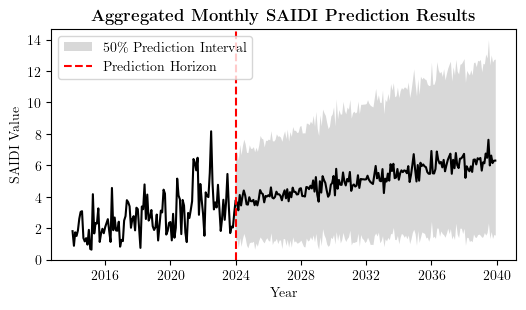

In [35]:
time = df__.pivot(index="month", columns="substation", values="SAIFI").index.values
time = pd.to_datetime(time)

plt.figure(figsize=[6, 3])
data = df__.pivot(index="month", columns="substation", values="SAIFI").values   # [ n_time, n_sub ]
plt.plot(time, data.sum(1), color = 'black')
plt.fill_between(
    time,
    df__.pivot(index="month", columns="substation", values="SAIFI Low").values.sum(1),
    df__.pivot(index="month", columns="substation", values="SAIFI High").values.sum(1),
    alpha = 0.3,
    label = r'50\% Prediction Interval',
    color = 'gray',
    lw = 0
)
plt.axvline(pd.Timestamp('2024-01-01'), label = 'Prediction Horizon', color = 'red', ls = '--')
plt.legend()
plt.xlabel('Year')
plt.title(rf'\bf Aggregated Monthly SAIDI Prediction Results')
plt.ylabel('SAIDI Value')
plt.show()

C:\Users\wenbi\AppData\Local\Temp\ipykernel_26036\3743135614.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


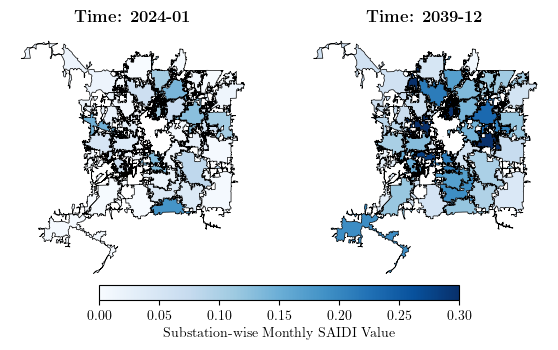

In [37]:
import geopandas as gpd
import numpy as np

gdf = gpd.read_file(r'data\substation_polygons\substation_polygons.shp')
df_pred = df__.pivot(index="month", columns="substation", values="SAIFI")


gdf_pre = gdf.copy()
gdf_pre['value'] = np.nan
for i in range(len(df_pred.columns)):
    col = df_pred.columns[i]
    mask = gdf_pre['substation'].astype(str).values == col
    gdf_pre.loc[mask, 'value'] = df_pred.iloc[0, i].astype(float)

gdf_post = gdf.copy()
gdf_post['value'] = np.nan
for i in range(len(df_pred.columns)):
    col = df_pred.columns[i]
    mask = gdf_post['substation'].astype(str).values == col
    gdf_post.loc[mask, 'value'] = df_pred.iloc[-1, i].astype(float)

cmap_name = 'Blues'

fig, axes = plt.subplots(1, 2, figsize = [6, 3])

gdf_list = [gdf_pre, gdf_post]
title_list = ['Time: 2024-01', 'Time: 2039-12']

for i in range(2):
    ax = axes[i]
    gdf_list[i].plot(
        ax = ax,
        column='value', cmap = cmap_name, legend=False, vmin = -0.0, vmax = 0.3,
        legend_kwds={"label": "Substation-wise Monthly SAIDI Value", "orientation": "vertical"}
    )
    gdf_list[i][~gdf_list[i]['value'].isna()].plot(ax = ax, edgecolor='black', lw = 0.5, facecolor = 'none' )
    ax.set_title(rf'\bf {title_list[i]}')
    ax.axis('off')

import matplotlib as mpl
cmap = plt.get_cmap(cmap_name)
norm = mpl.colors.Normalize(vmin=0, vmax=0.3)
cax = fig.add_axes([0.2, 0.0, 0.6, 0.05])  # adjust numbers for positioning
cb = mpl.colorbar.ColorbarBase(
    cax,
    cmap=cmap,
    norm=norm,
    orientation="horizontal"
)
cb.set_label("Substation-wise Monthly SAIDI Value")


plt.tight_layout()
# plt.savefig('fig/spatial.pdf', bbox_inches = 'tight')
plt.show()